# Driver Detection – Model Training & Feature Importance
This notebook trains a RandomForest model on features.csv and shows feature importance.

In [32]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
# Load dataset
df = pd.read_csv("features.csv")
df.head()

,EAR,Eye_State,Gaze_X,Gaze_Y,Head_Pitch,Head_Yaw,Head_Roll,Hand_Face_Dist,Label
0,0.047627,0,-23.333867,-6.695815,-62237.153153,-6052.141120,2750.021831,0.0,0
1,0.269485,2,-17.959864,-1.240389,62782.110285,9460.133135,-1580.582011,0.0,0
2,0.291108,2,-18.690927,-5.452183,-64060.558100,8151.029827,910.386901,0.0,0
3,0.215292,1,-34.950235,-8.978658,-63221.745336,-104.764537,525.120105,0.0,0
4,0.268348,2,-36.572126,-11.715698,-64462.201909,11230.693205,-293.833294,0.0,0


In [34]:
from useful_func import missing_info,out_info,clean_out

In [35]:
missing_info(df)

,col_name,num_missing_values,per_missing_values


In [36]:
out_info(df)

,col_name,method,num_outliers,%_outliers,uw,lw
0,Hand_Face_Dist,IQR,632,22.41,0.000000,0.000000
1,EAR,IQR,245,8.69,0.395355,0.106349
2,Gaze_Y,IQR,91,3.23,6.924533,-17.068189
3,Gaze_X,Z_Score,31,1.10,8.202274,-55.190386
4,Head_Yaw,Z_Score,10,0.35,31908.507585,-29111.462747


In [37]:

X = df.drop("Label", axis=1)
y = df["Label"]


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [39]:
# baseline model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8705673758865248

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       251
           1       0.89      0.87      0.88       313

    accuracy                           0.87       564
   macro avg       0.87      0.87      0.87       564
weighted avg       0.87      0.87      0.87       564

Confusion Matrix:

[[218  33]
 [ 40 273]]


In [41]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc  = accuracy_score(y_test, rf.predict(X_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 1.0
Test Accuracy : 0.8705673758865248


In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())


CV Scores: [0.87765957 0.86524823 0.86170213 0.85106383 0.84574468]
Mean CV Accuracy: 0.8602836879432625


In [43]:
# redifined model 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight={0:1,1:2},
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
print("Train Accuracy:", accuracy_score(y_train, rf.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

Train Accuracy: 0.8984929078014184
Test Accuracy: 0.8475177304964538


In [45]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())


CV Scores: [0.84751773 0.85638298 0.85106383 0.84219858 0.82978723]
Mean CV Accuracy: 0.8453900709219859


In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82       251
           1       0.83      0.91      0.87       313

    accuracy                           0.85       564
   macro avg       0.85      0.84      0.84       564
weighted avg       0.85      0.85      0.85       564



In [47]:
# Feature Importance
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
5,Head_Yaw,0.249048
7,Hand_Face_Dist,0.188586
6,Head_Roll,0.153856
3,Gaze_Y,0.119792
4,Head_Pitch,0.112361
0,EAR,0.087949
2,Gaze_X,0.069465
1,Eye_State,0.018941


In [48]:
feature_names = X.columns
feature_names

Index(['EAR', 'Eye_State', 'Gaze_X', 'Gaze_Y', 'Head_Pitch', 'Head_Yaw',
       'Head_Roll', 'Hand_Face_Dist'],
      dtype='object')

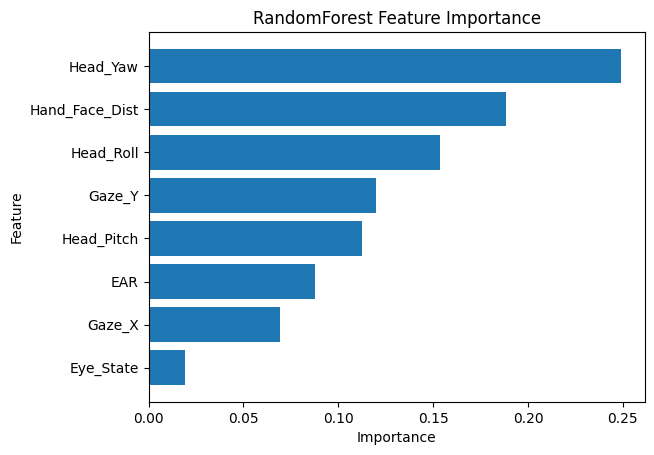

In [30]:
# Plot Feature Importance
plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("RandomForest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [31]:
# Save trained model
import joblib
joblib.dump(rf, "NEW_driver_model.pkl")
print("Model saved as new driver_model.pkl")

Model saved as new driver_model.pkl
